In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATA_BASE_PATH = "./malimg_paper_dataset_imgs/"

# compute class distribution
dist = {}
for mlw_class in os.listdir(DATA_BASE_PATH):
    mlw_dir = os.path.join(DATA_BASE_PATH, mlw_class)
    dist[mlw_class] = len(os.listdir(mlw_dir))

# HTB Color Palette
htb_green = "#9FEF00"
node_black = "#141D2B"
hacker_grey = "#A4B1CD"

classes = list(dist.keys())
frequencies = list(dist.values())

plt.figure(facecolor=node_black)
sns.barplot(y=classes, x=frequencies, edgecolor="black", orient='h', color=htb_green)
plt.title("Malware Class Distribution", color=htb_green)
plt.xlabel("Malware Class Frequency", color=htb_green)
plt.ylabel("Malware Class", color=htb_green)
plt.xticks(color=hacker_grey)
plt.yticks(color=hacker_grey)
ax = plt.gca()
ax.set_facecolor(node_black)
ax.spines['bottom'].set_color(hacker_grey)
ax.spines['top'].set_color(node_black)
ax.spines['right'].set_color(node_black)
ax.spines['left'].set_color(hacker_grey)
plt.show()

print("Total classes:", len(dist))
print("Total samples:", sum(dist.values()))
print("\nClass distribution:")
for k, v in sorted(dist.items(), key=lambda x: x[1], reverse=True):


SyntaxError: incomplete input (51825550.py, line 39)

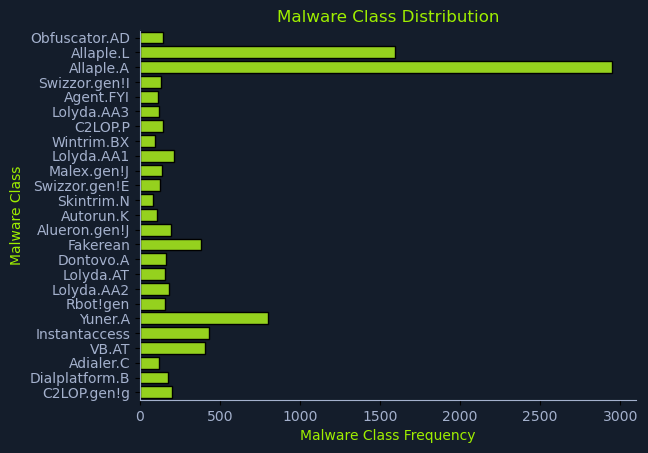

Total classes: 25
Total samples: 9339

Class distribution:
  Allaple.A: 2949
  Allaple.L: 1591
  Yuner.A: 800
  Instantaccess: 431
  VB.AT: 408
  Fakerean: 381
  Lolyda.AA1: 213
  C2LOP.gen!g: 200
  Alueron.gen!J: 198
  Lolyda.AA2: 184
  Dialplatform.B: 177
  Dontovo.A: 162
  Lolyda.AT: 159
  Rbot!gen: 158
  C2LOP.P: 146
  Obfuscator.AD: 142
  Malex.gen!J: 136
  Swizzor.gen!I: 132
  Swizzor.gen!E: 128
  Lolyda.AA3: 123
  Adialer.C: 122
  Agent.FYI: 116
  Autorun.K: 106
  Wintrim.BX: 97
  Skintrim.N: 80


In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATA_BASE_PATH = "./malimg_paper_dataset_imgs/"

# compute class distribution
dist = {}
for mlw_class in os.listdir(DATA_BASE_PATH):
    mlw_dir = os.path.join(DATA_BASE_PATH, mlw_class)
    dist[mlw_class] = len(os.listdir(mlw_dir))

# HTB Color Palette
htb_green = "#9FEF00"
node_black = "#141D2B"
hacker_grey = "#A4B1CD"

classes = list(dist.keys())
frequencies = list(dist.values())

plt.figure(facecolor=node_black)
sns.barplot(y=classes, x=frequencies, edgecolor="black", orient='h', color=htb_green)
plt.title("Malware Class Distribution", color=htb_green)
plt.xlabel("Malware Class Frequency", color=htb_green)
plt.ylabel("Malware Class", color=htb_green)
plt.xticks(color=hacker_grey)
plt.yticks(color=hacker_grey)
ax = plt.gca()
ax.set_facecolor(node_black)
ax.spines['bottom'].set_color(hacker_grey)
ax.spines['top'].set_color(node_black)
ax.spines['right'].set_color(node_black)
ax.spines['left'].set_color(hacker_grey)
plt.show()

print("Total classes:", len(dist))
print("Total samples:", sum(dist.values()))
print("\nClass distribution:")
for k, v in sorted(dist.items(), key=lambda x: x[1], reverse=True):
    print(f"  {k}: {v}")

In [3]:
import splitfolders
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import os

# Split dataset
DATA_BASE_PATH = "./malimg_paper_dataset_imgs/"
TARGET_BASE_PATH = "./newdata/"

splitfolders.ratio(input=DATA_BASE_PATH, output=TARGET_BASE_PATH, ratio=(0.8, 0, 0.2))

# Load datasets function
def load_datasets(base_path, train_batch_size, test_batch_size):
    transform = transforms.Compose([
        transforms.Resize((75, 75)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = ImageFolder(root=os.path.join(base_path, "train"), transform=transform)
    test_dataset = ImageFolder(root=os.path.join(base_path, "test"), transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False, num_workers=2)

    n_classes = len(train_dataset.classes)
    return train_loader, test_loader, n_classes

# Load
train_loader, test_loader, n_classes = load_datasets("./newdata/", 1024, 1024)
print(f"Classes: {n_classes}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Copying files: 9339 files [00:22, 424.15 files/s] 

Classes: 25
Train batches: 8
Test batches: 2


In [4]:
import torch
import torch.nn as nn
import torchvision.models as models

HIDDEN_LAYER_SIZE = 1000

class MalwareClassifier(nn.Module):
    def __init__(self, n_classes):
        super(MalwareClassifier, self).__init__()
        self.resnet = models.resnet50(weights='DEFAULT')
        
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, HIDDEN_LAYER_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_LAYER_SIZE, n_classes)
        )

    def forward(self, x):
        return self.resnet(x)

# Initialize
model = MalwareClassifier(n_classes)
print(model)
print(f"\nOutput classes: {n_classes}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/prakash/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:26<00:00, 3.83MB/s]


MalwareClassifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inpla

In [5]:
import torch
import time

def compute_accuracy(n_correct, n_total):
    return round(100 * n_correct / n_total, 2)

def train(model, train_loader, n_epochs, verbose=False):
    model.train()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())
    training_data = {"accuracy": [], "loss": []}
    
    for epoch in range(n_epochs):
        running_loss = 0
        n_total = 0
        n_correct = 0
        checkpoint = time.time() * 1000
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            n_total += labels.size(0)
            n_correct += predicted.eq(labels).sum().item()
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_duration = int(time.time() * 1000 - checkpoint)
        epoch_accuracy = compute_accuracy(n_correct, n_total)
        training_data["accuracy"].append(epoch_accuracy)
        training_data["loss"].append(epoch_loss)
        
        if verbose:
            print(f"[i] Epoch {epoch+1} of {n_epochs}: Acc: {epoch_accuracy:.2f}% Loss: {epoch_loss:.4f} (Took {epoch_duration} ms).")
    
    return training_data

def save_model(model, path):
    model_scripted = torch.jit.script(model)
    model_scripted.save(path)

def predict(model, test_data):
    model.eval()
    with torch.no_grad():
        output = model(test_data)
        _, predicted = torch.max(output.data, 1)
    return predicted

def evaluate(model, test_loader):
    model.eval()
    n_correct = 0
    n_total = 0
    with torch.no_grad():
        for data, target in test_loader:
            predicted = predict(model, data)
            n_total += target.size(0)
            n_correct += (predicted == target).sum().item()
    return compute_accuracy(n_correct, n_total)

# Run
DATA_PATH = "./newdata/"
N_EPOCHS = 10
TRAINING_BATCH_SIZE = 512
TEST_BATCH_SIZE = 1024
MODEL_FILE = "malware_classifier.pth"

train_loader, test_loader, n_classes = load_datasets(DATA_PATH, TRAINING_BATCH_SIZE, TEST_BATCH_SIZE)
model = MalwareClassifier(n_classes)

print("[i] Starting Training...")
training_information = train(model, train_loader, N_EPOCHS, verbose=True)

save_model(model, MODEL_FILE)

accuracy = evaluate(model, test_loader)
print(f"[i] Inference accuracy: {accuracy}%.")

[i] Starting Training...
[i] Epoch 1 of 10: Acc: 59.27% Loss: 1.4474 (Took 105323 ms).
[i] Epoch 2 of 10: Acc: 87.02% Loss: 0.4171 (Took 95033 ms).
[i] Epoch 3 of 10: Acc: 90.63% Loss: 0.2652 (Took 94007 ms).
[i] Epoch 4 of 10: Acc: 92.33% Loss: 0.2068 (Took 92599 ms).
[i] Epoch 5 of 10: Acc: 93.95% Loss: 0.1740 (Took 91999 ms).
[i] Epoch 6 of 10: Acc: 94.85% Loss: 0.1478 (Took 100531 ms).
[i] Epoch 7 of 10: Acc: 95.75% Loss: 0.1218 (Took 96898 ms).
[i] Epoch 8 of 10: Acc: 96.33% Loss: 0.1130 (Took 98725 ms).
[i] Epoch 9 of 10: Acc: 96.59% Loss: 0.1029 (Took 106729 ms).
[i] Epoch 10 of 10: Acc: 97.55% Loss: 0.0870 (Took 102588 ms).
[i] Inference accuracy: 89.63%.


In [6]:
accuracy = evaluate(model, test_loader)
print(f"[i] Inference accuracy: {accuracy}%.")

plot_training_accuracy(training_information)
plot_training_loss(training_information)

[i] Inference accuracy: 89.63%.


NameError: name 'plot_training_accuracy' is not defined

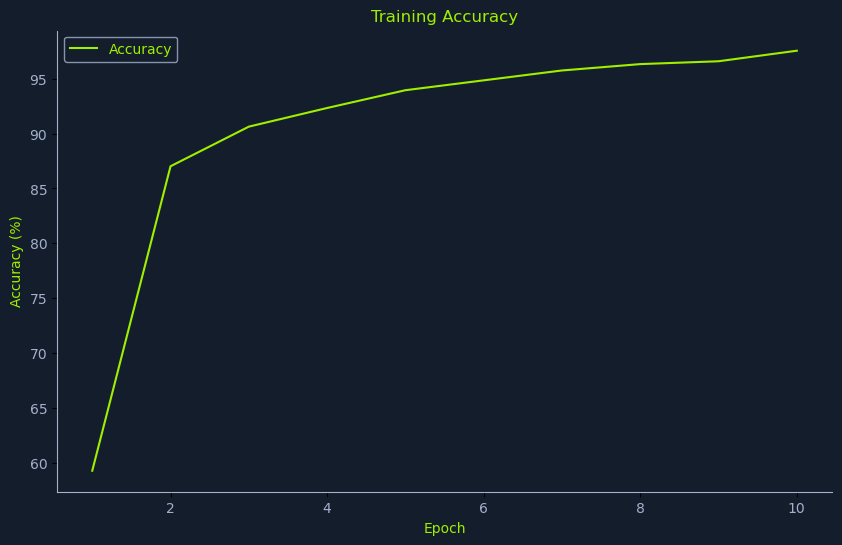

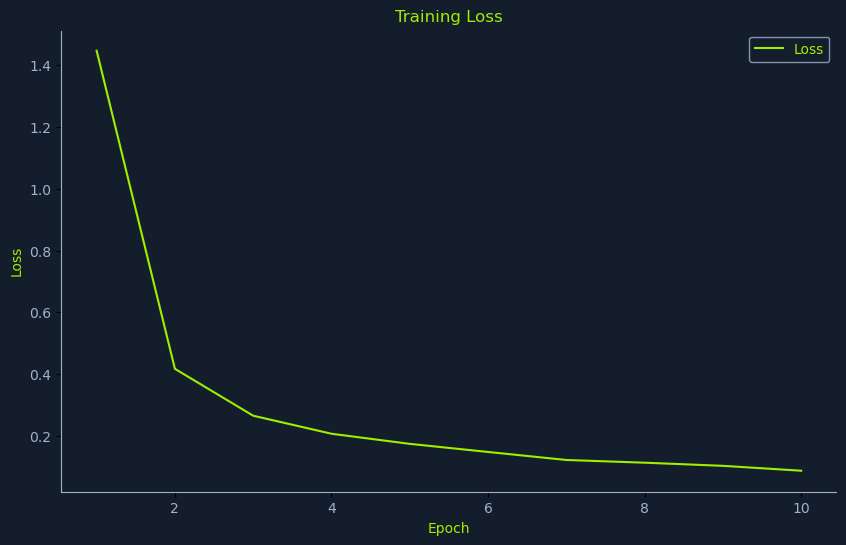

In [7]:
import matplotlib.pyplot as plt

def plot(data, title, label, xlabel, ylabel):
    htb_green = "#9FEF00"
    node_black = "#141D2B"
    hacker_grey = "#A4B1CD"

    plt.figure(figsize=(10, 6), facecolor=node_black)
    plt.plot(range(1, len(data)+1), data, label=label, color=htb_green)
    plt.title(title, color=htb_green)
    plt.xlabel(xlabel, color=htb_green)
    plt.ylabel(ylabel, color=htb_green)
    plt.xticks(color=hacker_grey)
    plt.yticks(color=hacker_grey)
    ax = plt.gca()
    ax.set_facecolor(node_black)
    ax.spines['bottom'].set_color(hacker_grey)
    ax.spines['top'].set_color(node_black)
    ax.spines['right'].set_color(node_black)
    ax.spines['left'].set_color(hacker_grey)
    legend = plt.legend(facecolor=node_black, edgecolor=hacker_grey, fontsize=10)
    plt.setp(legend.get_texts(), color=htb_green)
    plt.show()

def plot_training_accuracy(training_data):
    plot(training_data['accuracy'], "Training Accuracy", "Accuracy", "Epoch", "Accuracy (%)")

def plot_training_loss(training_data):
    plot(training_data['loss'], "Training Loss", "Loss", "Epoch", "Loss")

plot_training_accuracy(training_information)
plot_training_loss(training_information)

In [8]:
import requests
import json

url = "http://10.129.129.51:8002/api/upload"
model_file_path = "malware_classifier.pth"

with open(model_file_path, "rb") as model_file:
    files = {"model": model_file}
    response = requests.post(url, files=files)

print(json.dumps(response.json(), indent=4))

{
    "accuracy": 0.9669226225634967,
    "flag": "HTB{9569648083a8106ba057bbbe2d00d8ec}"
}
